In [30]:
import numpy as np

In [31]:
# run_dir = '/Users/akap5486/Projects/groundwater/data/henry_data/one_coupling_scenario/scenario_beta0.200_diffc0.00140/run_000001_hk864.00_por0.350_in2.8510_ghb1.0000'
# run_dir = '/Users/akap5486/Projects/groundwater/data/henry_data/grid_scenarios_20x40/scenarios/scenario_01/run_000001/'
run_dir = '/Users/arpitkapoor/Projects/groundwater/synthetic_problem/henry_mflab/debug_out_single_scenario/scenario_beta0.700_diffc0.57024/run_000001_in2.8510_'

In [32]:
windows = np.load(run_dir + '/windows.npz')
windows.files

['input_tensor',
 'output_tensor',
 'input_channel_names',
 't_index',
 't_lag_index',
 'time_t',
 'time_t_lag',
 'window_ids',
 'lag',
 'ncol',
 'nlay',
 'total_time',
 'nstp',
 'beta_c',
 'diffc',
 'hk',
 'por',
 'inflow',
 'ghb_head',
 'al',
 'at',
 'cinlet',
 'init_mode',
 'initial_head',
 'initial_concentration']

In [33]:
windows['input_tensor'].shape, windows['output_tensor'].shape

((99, 6, 20, 40), (99, 2, 20, 40))

In [34]:
# Plot conc and head at the first time step of the input tensor
import matplotlib.pyplot as plt
def plot_input_output_at_idx(windows, idx=0):
    input_tensor = windows['input_tensor']
    channel_names = windows['input_channel_names']

    # Decode channel names if stored as bytes
    channel_names = [
        name.decode('utf-8') if isinstance(name, (bytes, np.bytes_)) else str(name)
        for name in channel_names
    ]

    n_channels = input_tensor.shape[1]
    n_cols = min(3, n_channels)
    n_rows = int(np.ceil(n_channels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ch in range(n_channels):
        if ch == 0:
            cmap = 'Reds'
            axes[ch].set_title(f"{channel_names[ch]}")
        elif ch == 1:
            cmap = 'Blues'
            axes[ch].set_title(f"{channel_names[ch]}")
        else:
            cmap = 'Greens'
            axes[ch].set_title(f"{channel_names[ch]}: {input_tensor[idx, ch, :, :].max():.2f}" if ch < len(channel_names) else f'Channel {ch}')

        im = axes[ch].imshow(input_tensor[idx, ch, :, :], origin='upper', cmap=cmap)
        fig.colorbar(im, ax=axes[ch])

    # Hide any unused subplot axes
    for k in range(n_channels, len(axes)):
        axes[k].axis('off')

    plt.tight_layout()
    plt.show()


    fig, ax = plt.subplots(1, 2, figsize=(7, 2))

    im0 = ax[0].imshow(windows['output_tensor'][idx, 0, :, :], origin='upper', cmap='Reds')
    ax[0].set_title('Concentration')
    fig.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(windows['output_tensor'][idx, 1, :, :], origin='upper', cmap='Blues')
    ax[1].set_title('Head')
    fig.colorbar(im1, ax=ax[1])

    plt.tight_layout()
    plt.show()

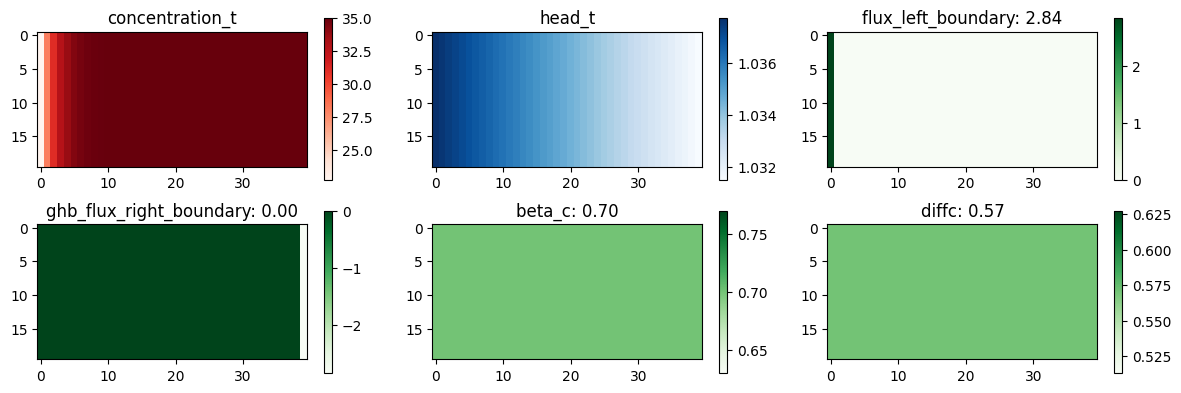

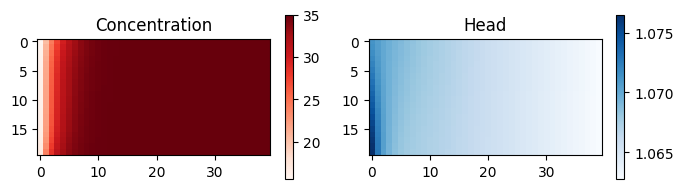

In [35]:
plot_input_output_at_idx(windows, idx=0)

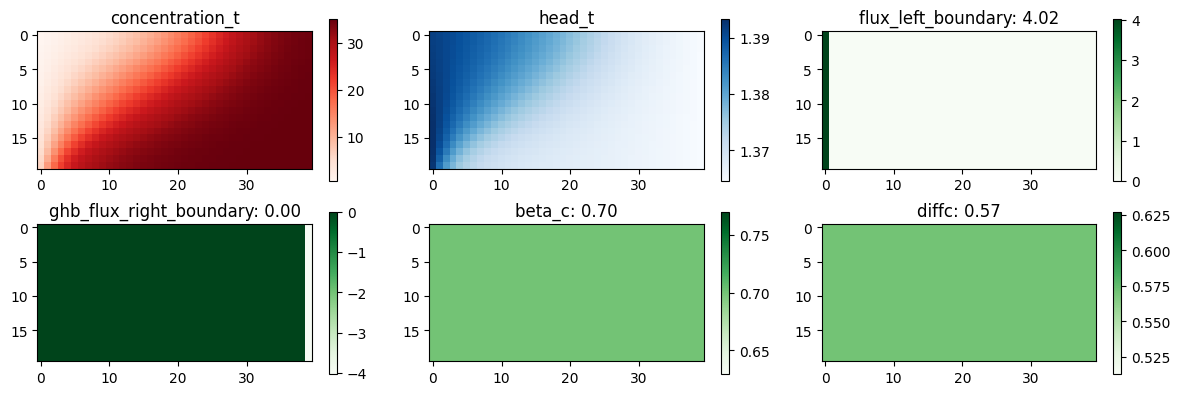

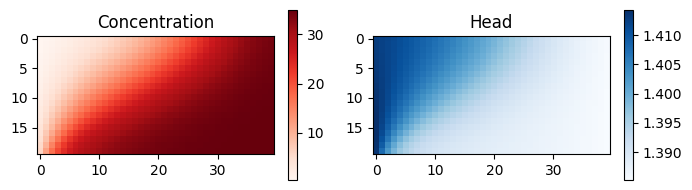

In [38]:
plot_input_output_at_idx(windows, idx=12)

/Users/arpitkapoor/Projects/groundwater/synthetic_problem/henry_mflab/.venv/lib/python3.12/site-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/Users/arpitkapoor/Projects/groundwater/synthetic_problem/henry_mflab/.venv/lib/python3.12/site-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/Users/arpitkapoor/Projects/groundwater/synthetic_problem/henry_mflab/.venv/lib/python3.12/site-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/Users/arpitkapoor/Projects/groundwater/synthetic_problem/henry_mflab/.venv/lib/python3.12/site-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserEleme

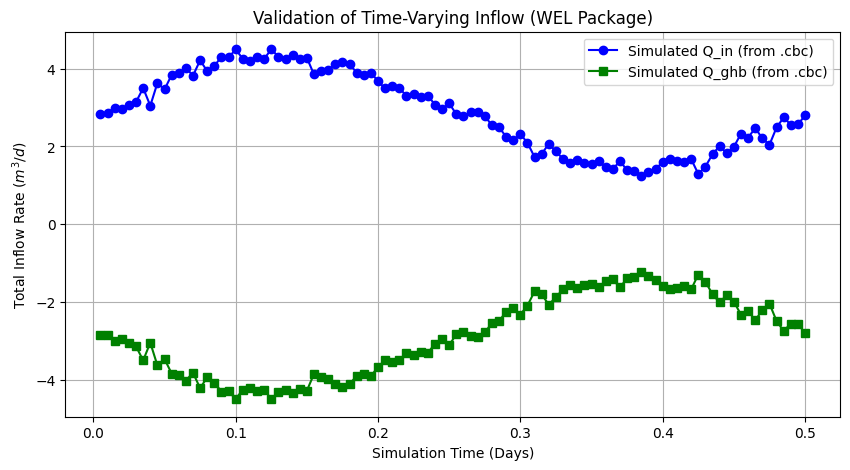

In [42]:
import flopy.utils.binaryfile as bf
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Point to your Cell-by-Cell file (update the filename to match your model name)
cbc_file = os.path.join(run_dir, "gwf.cbc") 

# 2. Open the binary budget file (MODFLOW 6 outputs in double precision)
cbc_obj = bf.CellBudgetFile(cbc_file, precision='double')

# 3. Get the list of all simulation times saved in the file
times = cbc_obj.get_times()

# 4. Extract the WEL package data
# Note: The text parameter usually matches the package name. If 'WEL' returns empty, 
# you can use cbc_obj.get_unique_record_names() to find the exact string.
wel_data = cbc_obj.get_data(text='WEL') 

# 5. Loop through the data to calculate total inflow per time step
actual_qin = []
for step_data in wel_data:
    # step_data is a numpy recarray containing ['node', 'q', etc.]
    # We sum the 'q' (flux) for all cells in the well boundary for this time step
    total_flux = np.sum(step_data['q']) 
    actual_qin.append(total_flux)


ghb_data = cbc_obj.get_data(text='GHB') 

# 5. Loop through the data to calculate total inflow per time step
qghb = []
for step_data in ghb_data:
    # step_data is a numpy recarray containing ['node', 'q', etc.]
    # We sum the 'q' (flux) for all cells in the GHB boundary for this time step
    total_flux = np.sum(step_data['q']) 
    qghb.append(total_flux)



# 6. Plot the extracted fluxes
plt.figure(figsize=(10, 5))
plt.plot(times, actual_qin, marker='o', linestyle='-', color='b', label='Simulated Q_in (from .cbc)')
plt.plot(times, qghb, marker='s', linestyle='-', color='g', label='Simulated Q_ghb (from .cbc)')
    
# Optional: Overlay your intended analytical formula to verify a perfect match
# intended_qin = inflow * (1 + 0.5 * np.sin(2 * np.pi * np.array(times) / total_time))
# plt.plot(times, intended_qin, linestyle='--', color='r', label='Intended Forcing')

plt.title("Validation of Time-Varying Inflow (WEL Package)")
plt.xlabel("Simulation Time (Days)")
plt.ylabel("Total Inflow Rate ($m^3/d$)")
plt.grid(True)
plt.legend()
plt.show()